# ECE1508: Deep Generative Models -- SUM25
## Assignment 1: Text Generation and Language Models
### Programming Part
This assignment reviews fundamental notions in language models, as well as some basic experiment with LLMs, in particular the BERT model. For each task, some explanations have been given and some starter code has been provided. Please complete the provided code and report your observations and conclusions for each part in the provided markdown. For submission, please pay attention to the instructions. Failure to following the instructions can lead to mark deduction.

### How to Answer?
Please complete all parts noted by `#COMPLETE`. Note that these parts are at both __Code__ and __Markdown.__


#### Let's start with loading necessary libraries.

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## Programming Question 1: Basic Context Aware LM
### General Overview
In this question, we implement a basic context aware LM. The architecture is shown below.

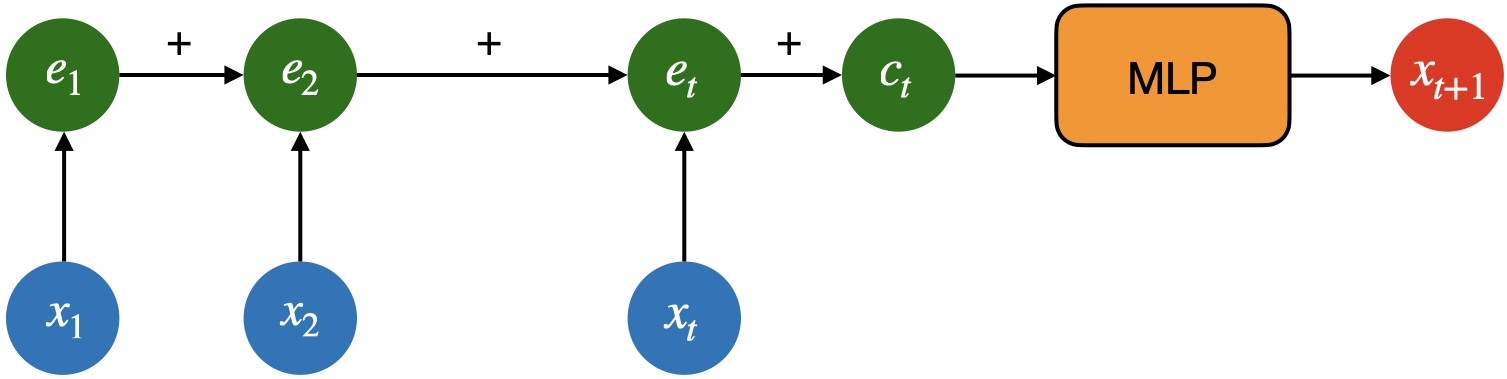

In [ ]:
from IPython.display import Image
Image(filename='Asgn1_Q1.jpeg', width=1100)

As shown in the architecture, to predict the next token, we build a context by __averaging__ the embeddings of all previous tokens, i.e.,

$$
\mathbf{c}_t = \frac{1}{t} \sum_{i=1}^t \mathbf{e}_i
$$

Assuming the embedding size to be `embd_size`, the MLP then use a linear layer to convert the context `c_t` of size `embd_size` to a logit vector of size `vocab_size'. The distribution of the next token is then set to be the softmax of the MLP output.

### Data
We train this model on the attached tiny text file named `corpus.txt`. We first load the corpus as a list of characters named `corpus`.

In [ ]:
filename = "corpus.txt"

# COMPLETE
## Read corpus as a list of characters
## Name the read list `corpus`
with open(filename, 'r', encoding='utf-8') as f:
    corpus = list(f.read())

Let's play around with the corpus to see what there is.

In [ ]:
print(len(corpus))
print(corpus[:150])

212623
['L', 'e', 't', "'", 's', ' ', 't', 'r', 'y', ' ', 's', 'o', 'm', 'e', 't', 'h', 'i', 'n', 'g', '.', '\n', 'I', ' ', 'h', 'a', 'v', 'e', ' ', 't', 'o', ' ', 'g', 'o', ' ', 't', 'o', ' ', 's', 'l', 'e', 'e', 'p', '.', '\n', 'T', 'o', 'd', 'a', 'y', ' ', 'i', 's', ' ', 'J', 'u', 'n', 'e', ' ', '1', '8', 't', 'h', ' ', 'a', 'n', 'd', ' ', 'i', 't', ' ', 'i', 's', ' ', 'M', 'u', 'i', 'r', 'i', 'e', 'l', "'", 's', ' ', 'b', 'i', 'r', 't', 'h', 'd', 'a', 'y', '!', '\n', 'M', 'u', 'i', 'r', 'i', 'e', 'l', ' ', 'i', 's', ' ', '2', '0', ' ', 'n', 'o', 'w', '.', '\n', 'T', 'h', 'e', ' ', 'p', 'a', 's', 's', 'w', 'o', 'r', 'd', ' ', 'i', 's', ' ', '"', 'M', 'u', 'i', 'r', 'i', 'e', 'l', '"', '.', '\n', 'I', ' ', 'w', 'i', 'l', 'l', ' ', 'b', 'e', ' ', 'b']


### Tokenization
For tokenization, we use a character level tokenization. This means that each character is a single token. To this end, we make a vocabulary of all available characters in the corpus and implement the `encode` and `decode` functions, which convert a text to index sequence and vice versa.

In [ ]:
# COMPLETE
## make a list including all characters in the corpus
## name it `vocab``
## print the number of characters, i.e., `len(vocab)`
vocab = sorted(set(corpus))
print(len(vocab))

# Write encode and decode function
char_to_token = {char:idx for idx,char in enumerate(vocab)}
token_to_char = {idx:char for idx,char in enumerate(vocab)}

encode = lambda text: [char_to_token[c] for c in text]# COMPLETE
## encode converts a text to token indices
decode = lambda tokens: ''.join([token_to_char[i] for i in tokens])# COMPLETE
## decode converts a token sequence to text

84


Let's try an example to confirm the implementation.

In [ ]:
text = 'this is the first Assignment!'

# convert to token seq
x = encode(text)
print(x)

# convert back to text
text_dec = decode(x)
print(text_dec)

[69, 57, 58, 68, 1, 58, 68, 1, 69, 57, 54, 1, 55, 58, 67, 68, 69, 1, 25, 68, 68, 58, 56, 63, 62, 54, 63, 69, 2]
this is the first Assignment!


### Implementing LM
We now implement the language model as illustrated in the question. Note that the implementation should take a __batch__ of sample texts as input.

In [ ]:
class ContextAwareLM(nn.Module):
    def __init__(self, vocab_size, embd_size):
        super(ContextAwareLM, self).__init__()

        # Embedding layer: each embedding is of size (embd_size)
        self.embedding = nn.Embedding(vocab_size, embd_size) # COMPLETE learning embedding matrix of size

        # Linear layer of MLP of size (embd_size, vocab_size)
        self.MLP = nn.Linear(embd_size, vocab_size) # COMPLETE

    def forward(self, x):
        """
        x: Tensor of shape (B, T+1), where B is batch size and T+1 is length of sample.
        """

        # Compute B and T
        B, T_plus_1 = x.size()
        T = T_plus_1 - 1

        # Get token embeddings for input sequence
        embeddings = self.embedding(x) # COMPLETE  # Apply Embedding. It should return objects of (B, T+1, embd_size)

        # Compute context at each time t=1,...,T
        ## You may find `torch.stack` useful
        context_list = []
        for t in range(1, T_plus_1):
          avg_embedding = embeddings[:, :t, :].mean(dim=1)  # (B, embd_size)
          context_list.append(avg_embedding)
        context =  torch.stack(context_list, dim=1)  # (B, T, embd_size) # COMPLETE

        # Compute final logits before Softmax
        logits = self.MLP(context) # COMPLETE  # (B, T, vocab_size)
        return logits

### Make batch of sequences
We next implement a function that makes a batch of text sequences.

In [ ]:
import random

# This function makes a random batch of size B, each sample being of length T
def get_batch(dataset, batch_size, seq_len, device):
    '''
    dataset: encoded text
    batch_size: B
    seq_len: T+1
    device: we will choose "mps", "cuda" or "cpu"
    '''

    # make sure we do not choose a start point with less that T+1 tokens to the end
    max_start = len(dataset) - seq_len # COMPLETE

    # initial empty batch
    samples = []

    # make a batch
    for _ in range(batch_size):
        start_idx = random.randint(0, max_start) # COMPLETE
        seq = dataset[start_idx : start_idx + seq_len] # COMPLETE  # sample a seq of length T+1
        samples.append(seq) # COMPLETE #append to `samples`

    # convert to Tensor and move to selected device
    x = torch.tensor(samples, dtype=torch.long).to(device=device)  # (B, T+1)
    return x

### Train LM
We now implement the training loop. First, let's fix the parameters.

In [ ]:
## Parameters

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"
# Batch parameters
B = 32            # Batch size
T = 64            # Sample length

# Embedding and vocab_size
embd_size = 128              # Embedding size
vocab_size = len(vocab)      # Vocab size

# Training loop parameters
learning_rate = 1e-3
num_iters = 1000

# Encode corpus to a dataset
dataset = encode(corpus) # COMPLETE # encode the whole corpus

import torch.optim as optim
# Model, loss, optimizer
model = ContextAwareLM(vocab_size, embd_size).to(device=device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # COMPLETE #choose right loss

We now complete the training loop.

In [ ]:
# we save the loss after every 100 iterations
log_interval = 100

# Training loop
loss_history = []

for step in range(num_iters):
    model.train()
    x = get_batch(dataset, B, T + 1, device)  # COMPLETE  # get a batch of (B, T+1)
    logits = model(x) # COMPLETE     # pass through the model -> (B, T, vocab_size)
    targets = x[:, 1:] # COMPLETE    # make labels using next tokens in the sentence ->(B, T)

    loss = criterion(logits.view(-1, vocab_size), targets.reshape(-1)) # COMPLETE # compute loss between logits and targets
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % log_interval == 0:
        print(f"Step {step+1}: Loss = {loss.item():.4f}")
        loss_history.append(loss.item())

Step 1: Loss = 4.4009
Step 101: Loss = 3.0887
Step 201: Loss = 3.0418
Step 301: Loss = 2.9888
Step 401: Loss = 2.9941
Step 501: Loss = 3.0332
Step 601: Loss = 2.9625
Step 701: Loss = 2.9782
Step 801: Loss = 2.9926
Step 901: Loss = 2.9511


### Comparing to Maximum Entropy bound
The cross entropy is always upper-bounded by the maximum entropy of a single character which is

$$
\mathrm{Cross-Entropy} \leq H(x_{t+1} \vert x_1, \ldots, x_t) \leq H(x_{t+1}) \leq \ln (\vert V \vert)
$$

Where $H$ is the entropy (information-theoretic metric), and $\vert V \vert$ denotes the `vocab_size`. We now plot the training curve and compare it to this upper bound. To this end, run the following code.

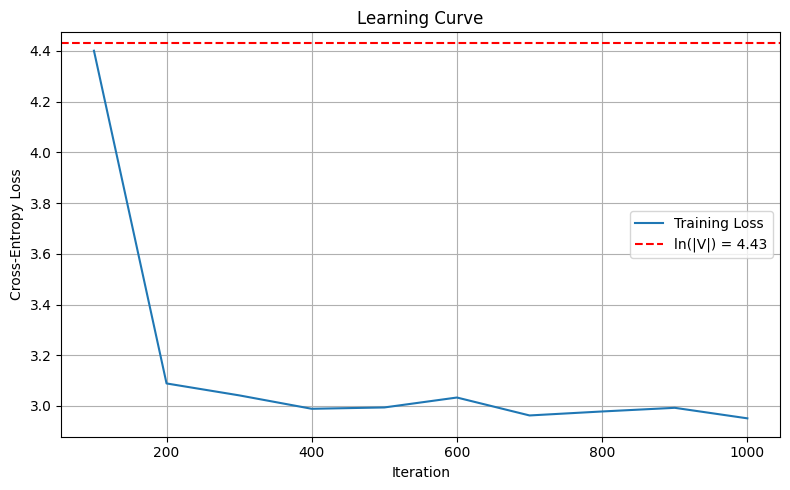

In [ ]:
import matplotlib.pyplot as plt
import math

# Plotting learning curve
plt.figure(figsize=(8, 5))
plt.plot(range(log_interval, num_iters + 1, log_interval), loss_history, label="Training Loss")
upper_bound = math.log(vocab_size)
plt.axhline(upper_bound, color='red', linestyle='--', label=f"ln(|V|) = {upper_bound:.2f}")
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Question: _Explain your observation._
`# COMPLETE`

At the beginning, the model is randomly guessing the next word, with loss close to the maximum entropy of a uniform distribution over the vocabulary; then loss decreases with training, the model is able to assign higher probability to the correct next token.

### Generating Text
We now write a Code that completes an incomplete text. At this point, we do a minor change: when we want to compute probabilities from the logits, we apply __temperature__ $\theta$ as follows

$$
P(x_{t+1} \vert c_t) = \mathrm{Softmax} ( \frac{\mathrm{logits}}{\theta} )
$$

By setting $\theta= 1$ this reduces to the basic generation. However, we can play with $\theta$ to increase or reduce the randomness of the sampled token.

In [ ]:
def generate_text(model, prompt, max_new_tokens, temperature = 1.0):
    '''
    model: trained LM
    prompt: incomplete text
    max_new_tokens: maximum new tokens generated by the model
    temperature: theta in the above formula
    '''
    model.eval()

    # Start with encoded prompt
    context = encode(prompt) # COMPLETE # encode text, truncate if needed
    generated = context[:] # copy of context

    for _ in range(max_new_tokens):
        # make input to be a tensor
        x = torch.tensor(generated[-T:], dtype=torch.long, device=device).unsqueeze(0) # only need last T tokens to compute context

        if x.size(1) < T + 1:
            # Pad with dummy tokens (e.g., zeros) to make size T+1
            pad_len = T + 1 - x.size(1) # COMPLETE
            pad = torch.zeros((1, pad_len), dtype=torch.long, device=device)
            x = torch.cat([pad, x], dim=1) # COMPLETE #add dummy tokens to x ## you may use torch.cat

        with torch.no_grad():
            logits = model(x) # COMPLETE  # (1, T, vocab_size)
            next_token_logits = logits[0, -1, :]  # COMPLETE  # get last logit, (batch idx, time idx, vocab idx)

            # Apply temperature
            next_token_logits_with_temp = next_token_logits / temperature # COMPLETE

            # find distribution
            probs = torch.softmax(next_token_logits_with_temp, dim=-1) # COMPLETE

            # Sample from distribution
            next_token = torch.multinomial(probs, num_samples=1).item() # COMPLETE

        generated.append(next_token)

    return decode(generated)


Let's now complete a text with only two characters.

In [ ]:
prompt = "This is a book. The"
generate_text(model, prompt, 2, temperature=1)

'This is a book. ThehC'

In [ ]:
temperatures = [0.2, 0.3, 0.5, 1.0, 2.0]
prompt = "This is a book. The"

for temp in temperatures:
    result = generate_text(model, prompt, 20, temperature=temp)
    print(f"Temperature {temp}: {result}")

Temperature 0.2: Once upon a time, a kingIIIho  ho o  ooooo u
Temperature 0.3: Once upon a time, a kingoIYhIoo Io oo    o o
Temperature 0.5: Once upon a time, a kinghoYhoIehIooI uuo o  
Temperature 1.0: Once upon a time, a kingWtIlDCTAoCsreeih w  
Temperature 2.0: Once upon a time, a kingR√lY:AOob'meoptW dvu


### Question: _What do you conclude?_
`# COMPLETE`

Low temperature predict more deterministic and repetitive next character, favoring common continuations seen in training data.

High temperature predictions are more varied/random.


### Question: _Play with the temperature. What do you observe? What is your conclusion?_
`# COMPLETE`

Lower temperature should mean less randomness. But this model is very simple and there is very few training data, the output still noisy/not making much sense even at low temperature.

## Programming Question 2: BERT Model and its Fine-tuning
BERT is a well-known transformer-based pre-trained LM. It is mainly used for __text classification__; therefore, it does __not__ have masked decoding. It however give the option to import some tokens as `"[MASK]"` to approximately mimic the masked decoding behavior. In this question, we first import the pre-trained BERT, and use it with Mask to complete a text. In the second part, we take a small subset of IMDB dataset to fine-tune it for text classification and see the impacts of fine-tuning.

### Installing Required Package
Let's first install all we need.


In [ ]:
# Install transformers. We can also do it directly at the terminal
# %pip install -q datasets transformers

In [ ]:
! pip install transformers

### Text Completion by Masked BERT
Now, let's import BERT. As mentioned, this model does not have masked decoding directly implemented. This means that in each time, the context is computed from both past and future tokens. We can though use the class `BertForMaskedLM` and mimic the masked decoding behavior by replacing unknown tokens with special token `[MASK]`.

In [ ]:
from transformers import BertTokenizer, BertForMaskedLM

# Select the device
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

# Load pre-trained Tokenizer and the BERT model with masked head
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name)

model.eval()
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [ ]:
def bert_masked_completion(text, num_masks=5, temperature=1.0):
    '''
    text: incomplete text
    num_masks: indicating number of tokens being added to the text.
    temperature: the temperature by which we sample
    '''
    # Append [MASK] tokens to the incomplete text
    masked_text = text + " " + " ".join(["[MASK]"] * num_masks) # COMPLETE
    print("Input Text:", masked_text)

    for i in range(num_masks):
        # Tokenize input
        inputs = tokenizer(masked_text, return_tensors="pt").to(device) # COMPLETE use `tokenizer` to tokenize `masked_text`

        # Predict all masked tokens
        with torch.no_grad():
            outputs = model(**inputs) # ** to unpack inputs in dict format to (v1=value1, v2=val2, ..)
            logits = outputs.logits # (batch_size, sequence_length, vocab_size)

        # Find the first token [MASK] in the input
        # inputs["input_ids"] is a tensor of token IDs representing input text
        # tokenizer.mask_token_id is the token ID for `[MASK]`
        # inputs["input_ids"] == tokenizer.mask_token_id givens a tensor of booleans
        # torch.where return (batch_idx, token_idx), so [1] to get token_idx where token is [MASK]
        mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1] # COMPLETE
        # Save position of the first [MASK]
        mask_pos = mask_token_index[0] # COMPLETE

        # Compute the probability distribution with temperature
        logits_mask = logits[0, mask_pos] / temperature # get first batch, at mask_pos row, for a vector of len vocab
        probs = F.softmax(logits_mask, dim=-1) # COMPLETE
        # Sample from the distribution
        predicted_token_id = torch.multinomial(probs, num_samples=1).item() # COMPLETE
        predicted_token = tokenizer.decode([predicted_token_id])

        # Replace first [MASK] with predicted token
        tokenized_text = tokenizer.tokenize(masked_text)
        mask_pos_in_tokens = tokenized_text.index("[MASK]")
        tokenized_text[mask_pos_in_tokens] = predicted_token

        # Update masked_text for next iteration
        masked_text = tokenizer.convert_tokens_to_string(tokenized_text)

        print(f"Predicted token at t+{i+1}:", predicted_token)
        print("Current text:", masked_text)

    print("\nFinal completed text:", masked_text)

We now complete a text with this model.

In [ ]:
text = "The movie was"
# Example usage
bert_masked_completion(text, num_masks=5)

Input Text: The movie was [MASK] [MASK] [MASK] [MASK] [MASK]
Predicted token at t+1: ranked
Current text: the movie was ranked [MASK] [MASK] [MASK] [MASK]
Predicted token at t+2: at
Current text: the movie was ranked at [MASK] [MASK] [MASK]
Predicted token at t+3: number
Current text: the movie was ranked at number [MASK] [MASK]
Predicted token at t+4: eight
Current text: the movie was ranked at number eight [MASK]
Predicted token at t+5: .
Current text: the movie was ranked at number eight .

Final completed text: the movie was ranked at number eight .


In [ ]:
bert_masked_completion(text, num_masks=5,temperature=0.5)

Input Text: The movie was [MASK] [MASK] [MASK] [MASK] [MASK]
Predicted token at t+1: an
Current text: the movie was an [MASK] [MASK] [MASK] [MASK]
Predicted token at t+2: instant
Current text: the movie was an instant [MASK] [MASK] [MASK]
Predicted token at t+3: ##aneous
Current text: the movie was an instantaneous [MASK] [MASK]
Predicted token at t+4: success
Current text: the movie was an instantaneous success [MASK]
Predicted token at t+5: .
Current text: the movie was an instantaneous success .

Final completed text: the movie was an instantaneous success .


In [ ]:
bert_masked_completion(text, num_masks=5,temperature=2)

Input Text: The movie was [MASK] [MASK] [MASK] [MASK] [MASK]
Predicted token at t+1: costing
Current text: the movie was costing [MASK] [MASK] [MASK] [MASK]
Predicted token at t+2: stop
Current text: the movie was costing stop [MASK] [MASK] [MASK]
Predicted token at t+3: photo
Current text: the movie was costing stop photo [MASK] [MASK]
Predicted token at t+4: heat
Current text: the movie was costing stop photo heat [MASK]
Predicted token at t+5: .
Current text: the movie was costing stop photo heat .

Final completed text: the movie was costing stop photo heat .


### Question: _Play around with the temperature. What do you see?_
`# COMPLETE`

smaller temperature is conservative; 1 is balanced; larger temperature generates creative but meaningless words.

### Pre-trained BERT for Classification
We next fine-tune the model `BertForSequenceClassification` for text classification. To this end, we use a small subset of the `"imdb"` dataset. Let's first build the data.

In [ ]:
! pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
from datasets import load_dataset

# Load the IMDB dataset
dataset = load_dataset("imdb") # COMPLETE # load "imdb"

# Sample one example
print(dataset["train"][10])


# Sample a small subset of D_train samples for training and D_test for testing
D_train, D_test = 1000, 500
small_train_dataset = dataset["train"].select(range(D_train)) # COMPLETE
small_test_dataset = dataset["test"].select(range(D_test)) # COMPLETE

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

{'text': 'It was great to see some of my favorite stars of 30 years ago including John Ritter, Ben Gazarra and Audrey Hepburn. They looked quite wonderful. But that was it. They were not given any characters or good lines to work with. I neither understood or cared what the characters were doing.<br /><br />Some of the smaller female roles were fine, Patty Henson and Colleen Camp were quite competent and confident in their small sidekick parts. They showed some talent and it is sad they didn\'t go on to star in more and better films. Sadly, I didn\'t think Dorothy Stratten got a chance to act in this her only important film role.<br /><br />The film appears to have some fans, and I was very open-minded when I started watching it. I am a big Peter Bogdanovich fan and I enjoyed his last movie, "Cat\'s Meow" and all his early ones from "Targets" to "Nickleodeon". So, it really surprised me that I was barely able to keep awake watching this one.<br /><br />It is ironic that this movie is a

For tokenization, we use `BertTokenizerFast` as it helps us process faster.

In [ ]:
from transformers import BertTokenizerFast

# Load BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Tokenize one example
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=256)

tokenized_train = small_train_dataset.map(tokenize_function, batched=True) # COMPLETE # you may use `.map` method
tokenized_test = small_test_dataset.map(tokenize_function, batched=True) # COMPLETE # you may use `.map` method

# Show tokenized sample
print(tokenized_train[0])

# Set format for PyTorch
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

We next test the pre-trained model on the test set to see its pre-trained performance.

In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Create a DataLoader for test set
test_dataloader = DataLoader(tokenized_test, batch_size=16)

# Move model to device at eval mode
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)
model.eval()


# Set counter for number of correct prediction
correct = 0
total = 0

# No gradient calculation needed during evaluation
with torch.no_grad():
    for batch in tqdm(test_dataloader):
        input_ids = batch["input_ids"].to(device)# COMPLETE
        attention_mask = batch["attention_mask"].to(device) # COMPLETE
        labels = batch["label"].to(device) # COMPLETE

        # compute context
        outputs = model(input_ids=input_ids, attention_mask=attention_mask) # COMPLETE
        # Find the class with "maximum" logit
        predictions = torch.argmax(outputs.logits, dim=1) # COMPLETE, along row, 2 class: 0 or 1 (neg or posi review)

        # compute number of correct predictions
        correct += (predictions == labels).sum().item() # COMPLETE .item():convert tensor to number
        total += labels.size(0) # COMPLETE # update total number of samples

# Compute accuracy
accuracy = correct / total
print(f"Pretrained BERT accuracy on test set: {accuracy:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 32/32 [00:06<00:00,  4.82it/s]

Pretrained BERT accuracy on test set: 0.9960


### Fine-tuning BERT
We now fine-tune BERT on the train dataset. We use __Selective Fine-tuning,__ where we only fine-tune the last encoder (transformer) layer and the final MLP (classification head). We can freeze all other layers using the following code.

In [ ]:
# Freeze all BERT parameters
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze only the last encoder layer
last_layer_idx = 11
for param in model.bert.encoder.layer[last_layer_idx].parameters():
    param.requires_grad = True

# Also unfreeze the classifier head
for param in model.classifier.parameters():
    param.requires_grad = True


For fine-tuning, we use __LoRA__ algorithm with rank $\ell=8$. This can be directly implemented using the `pfet` library. The following code builds the required configurations.

In [ ]:
from peft import get_peft_model, LoraConfig, TaskType

# LoRA config — tune the hyperparameters as you wish
lora_config = LoraConfig(
    r = 8, # rank of LoRA, i.e., l in the lecture-notes
    lora_alpha = 32,     # scaling factor
    target_modules = ["query", "value"],  # target attention modules for LoRA:Q and V
    lora_dropout = 0.1,
    bias = "none",
    task_type = TaskType.SEQ_CLS,# seq classification: entire input text is assigned a class
)

# Apply LoRA to the model -> This will apply LoRA to unfrozen layers
model = get_peft_model(model, lora_config)

We can readily perform the fine tuning using the `Trainer` class. The following code defines the `trainer` which can be used to fine-tune the model over our dataset. We set the the number of fine-tuning epochs to 3.

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",        # <-- add this line
    learning_rate=5e-4,
    per_device_train_batch_size = 16,# COMPLETE #set it to the batch-size of the dataloader
    per_device_eval_batch_size = 16,# COMPLETE
    num_train_epochs= 3,# COMPLETE
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
)


# The tokenized_train and tokenized_test datasets must have format set for torch tensors:
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,

)

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


We can now fine-tune easily by applying method `.train()` to the `trainer`.

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: joy-gong33 (joy-gong33-university-of-toronto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.000000,0.000014
2,0.000000,0.000012
3,0.000000,0.000011


TrainOutput(global_step=189, training_loss=0.007678538204999838, metrics={'train_runtime': 147.8396, 'train_samples_per_second': 20.292, 'train_steps_per_second': 1.278, 'total_flos': 396032624640000.0, 'train_loss': 0.007678538204999838, 'epoch': 3.0})

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs= 3,
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,

)
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss
1,0.112200,0.076161
2,0.015300,0.011693
3,0.009400,0.008308


TrainOutput(global_step=189, training_loss=0.10923084667908452, metrics={'train_runtime': 111.4691, 'train_samples_per_second': 26.913, 'train_steps_per_second': 1.696, 'total_flos': 396032624640000.0, 'train_loss': 0.10923084667908452, 'epoch': 3.0})

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs= 3,
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,

)
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000


TrainOutput(global_step=189, training_loss=0.005643040769626324, metrics={'train_runtime': 110.3161, 'train_samples_per_second': 27.195, 'train_steps_per_second': 1.713, 'total_flos': 396032624640000.0, 'train_loss': 0.005643040769626324, 'epoch': 3.0})

### Question: _Play around with the learning rate at `training_args` to see the impact. Report what you see._
`# COMPLETE`

tried lr = [5e-3, 5e-4, 5e-5]

5e-3: All losses are extremely close to 0 from the start

5e-4: Training losses are extremely close to 0 from the start, validation loss steadily decrease

5e-5: Training loss and validation loss steadily decrease.

use lr = 5e-4 makes most sense

Let's now evaluate the fine-tuned model.

In [ ]:
# Set model back to eval
model.eval()

# Set prior values
correct = 0
total = 0

# evaluation loop
with torch.no_grad():
    for batch in tqdm(test_dataloader):
        input_ids = batch["input_ids"].to(device) # COMPLETE
        attention_mask = batch["attention_mask"].to(device) # COMPLETE
        labels = batch["label"].to(device) # COMPLETE

        # compute context
        outputs = model(input_ids=input_ids, attention_mask=attention_mask) # COMPLETE
        # Find the class with "maximum" logit
        predictions = torch.argmax(outputs.logits, dim=1) # COMPLETE

        # compute number of correct predictions
        correct += (predictions == labels).sum().item() # COMPLETE # add the number of correct classifications
        total += labels.size(0) # COMPLETE # update total number of samples

# Compute accuracy
accuracy = correct / total
print(f"Fine_tuned BERT accuracy on small test set: {accuracy:.4f}")


100%|██████████| 32/32 [00:07<00:00,  4.48it/s]

Fine_tuned BERT accuracy on small test set: 1.0000


### Question: _Compare the fine-tuned accuracy to that of the pre-trained one. What do you conclude?_
`# COMPLETE`

- Pretrained BERT accuracy on test set: 0.8980
- Fine_tuned BERT accuracy on small test set: 1.0000
- Fine tuning helps the model better at the specific task: review classification (negative or positive).